In [1]:
import json
import numpy as np
import pandas as pd
from sklearn.feature_extraction import text
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
import sklearn.preprocessing as preproc

#### Load Yelp datasets

In [2]:
# Load the Yelp business dataset using pandas read_json
# Added lines=True to designate each line to represent a complete JSON object
biz_f = open('yelp_academic_dataset_business.json','r', encoding='utf-8')
biz_df = pd.DataFrame([json.loads(x) for x in biz_f.readlines()])
biz_f.close()
biz_df.shape

(150346, 14)

In [3]:
from langdetect import detect, LangDetectException

# Open a json file in read mode
f = open('yelp_academic_dataset_review.json','r', encoding='utf-8')
js = []

# Append the first 10,000 rows into a dataset if the text is English
i = 0
while i < 10000:
    jrl = json.loads(f.readline())
    if detect(jrl['text']) =='en':
        #print(jrl)
        js.append(jrl)
        i +=1    
f.close()
review_df = pd.DataFrame(js)

# Return the shape
review_df.shape

(10000, 9)

In [4]:
biz_df['categories'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 150346 entries, 0 to 150345
Series name: categories
Non-Null Count   Dtype 
--------------   ----- 
150243 non-null  object
dtypes: object(1)
memory usage: 1.1+ MB


In [5]:
# Fill missing category values with 'None'
biz_df['categories'] = biz_df['categories'].fillna(value='None')

biz_df['categories'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 150346 entries, 0 to 150345
Series name: categories
Non-Null Count   Dtype 
--------------   ----- 
150346 non-null  object
dtypes: object(1)
memory usage: 1.1+ MB


In [6]:
# Filter out only restaurants with Nightlife 
two_biz = biz_df[biz_df.apply(
    lambda x: 'Nightlife' in x['categories'] or
    'Restaurants' in x['categories'], axis=1)]
two_biz.shape

(55826, 14)

In [7]:
# Join the review and business sets on business_id
twobiz_reviews = two_biz.merge(review_df, on="business_id", how="inner")
twobiz_reviews.shape

(7421, 22)

In [8]:
# Use only features needed
twobiz_reviews = twobiz_reviews[['business_id','name','stars_y',
                                 'text','categories']]

# Display the first 2 rows
twobiz_reviews.head(2)

,business_id,name,stars_y,text,categories
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,4.0,This is nice little Chinese bakery in the hear...,"Restaurants, Food, Bubble Tea, Coffee & Tea, B..."
1,0bPLkL0QhhPO5kt1_EXmNQ,Zio's Italian Market,1.0,The worst Chicken Parm. Sandwich I've ever eat...,"Food, Delis, Italian, Bakeries, Restaurants"


#### Create Classification Dataset

In [9]:
# Extract reviews with nightlife and restaurant categories into separate datasets
nightlife = twobiz_reviews[twobiz_reviews.apply(lambda x:
                                                'Nightlife' in x['categories'],
                                                axis=1)]
restaurants = twobiz_reviews[twobiz_reviews.apply(lambda x:
                                                  'Restaurants' in x['categories'],
                                                  axis=1)]
print(nightlife.shape)
print(restaurants.shape)

(2260, 5)
(7106, 5)


In [10]:
# Balance to two subsets
nightlife_subset = nightlife
restaurants_subset = restaurants.sample(frac=0.318, random_state=123)
print(nightlife_subset.shape)
print(restaurants_subset.shape)

(2260, 5)
(2260, 5)


In [11]:
# Combine the two datasets
combined = pd.concat([nightlife_subset, restaurants_subset])

In [12]:
# Add target value to dataset based on Nightlife being in the category
combined['target'] = combined.apply(lambda x: 
                                    'Nightlife' in x['categories'],
                                    axis=1)

In [13]:
combined.head(3)

,business_id,name,stars_y,text,categories,target
11,WKMJwqnfZKsAae75RMP6jA,Roast Coffeehouse and Wine Bar,3.0,So much to like about this place--the beautifu...,"Coffee & Tea, Food, Cafes, Bars, Wine Bars, Re...",True
12,WKMJwqnfZKsAae75RMP6jA,Roast Coffeehouse and Wine Bar,4.0,I'm not a coffee connoisseur so I'm not review...,"Coffee & Tea, Food, Cafes, Bars, Wine Bars, Re...",True
18,QdN72BWoyFypdGJhhI5r7g,Bar One,5.0,"This place is top notch, with phenomenal servi...","Cocktail Bars, Bars, Italian, Nightlife, Resta...",True


In [14]:
# Validate the target values
combined['target'].unique()

array([ True, False])

In [15]:
# Split the data into training and test datasets
training_data, test_data = train_test_split(combined,
                                            train_size=0.2,
                                            random_state=123)
print(training_data.shape)
print(test_data.shape)

(904, 6)
(3616, 6)


#### Bag-of-Words with Tf-Idf Transformation

In [16]:

bow_transform = text.CountVectorizer()
X_tr_bow = bow_transform.fit_transform(training_data['text'])
X_te_bow = bow_transform.transform(test_data['text'])

print(len(bow_transform.vocabulary_))
print(X_tr_bow.shape)
print(X_te_bow.shape)           

6857
(904, 6857)
(3616, 6857)


In [17]:
y_tr = training_data['target']
y_te = test_data['target']

In [18]:
# Create the training and test tf-idf representation using the bag-of-words matrix
tfidf_trfm = text.TfidfTransformer(norm=None)
X_tr_tfidf = tfidf_trfm.fit_transform(X_tr_bow)
X_te_tfidf = tfidf_trfm.transform(X_te_bow)

In [19]:
# Normalize the training and testing bag-of-words arrays 
X_tr_l2 = preproc.normalize(X_tr_bow, axis=0)
X_te_l2 = preproc.normalize(X_te_bow, axis=0)

#### Classify with Logistic Regression

In [20]:
def simple_logistic_classify(X_tr, y_tr, X_test, y_test, description, _C=1.0):
    ## Helper function to train a logistic classifier and score on test data
    m = LogisticRegression(C=_C).fit(X_tr, y_tr)
    s = m.score(X_test, y_test)
    print('Test score with', description, 'features:', s)
    return m

In [21]:
# Retrieve the testing score for bow, l2, and tf-idf
m1 = simple_logistic_classify(X_tr_bow, y_tr, X_te_bow, y_te, 'bow')
m2 = simple_logistic_classify(X_tr_l2, y_tr, X_te_l2, y_te, 'l2-normalized')
m3 = simple_logistic_classify(X_tr_tfidf, y_tr, X_te_tfidf, y_te, 'tf-idf')

Test score with bow features: 0.6985619469026548
Test score with l2-normalized features: 0.6568030973451328
Test score with tf-idf features: 0.7085176991150443


#### Tune Regularization Parameters With Gridsearch

In [22]:
# Perform a grid search on the bow, l2, and tf-idf 
param_grid = {'C': [1e-5, 1e-3, 1e-1, 1e0, 1e1, 1e2]}

bow_search = GridSearchCV(LogisticRegression(), 
                          cv=5,
                          param_grid=param_grid)
l2_search = GridSearchCV(LogisticRegression(),
                          cv=5,
                          param_grid=param_grid)
tfidf_search = GridSearchCV(LogisticRegression(),
                            cv=5,
                            param_grid=param_grid)


In [23]:
# Get the best score and parameters for bow
bow_search.fit(X_tr_bow, y_tr)
print(f'Best score: {bow_search.best_score_}')
print(f'Best parameters: {bow_search.best_params_}')

Best score: 0.6648066298342541
Best parameters: {'C': 0.1}


In [24]:
# Get the best score and parameters for L2
l2_search.fit(X_tr_l2, y_tr)
print(f'Best score: {l2_search.best_score_}')
print(f'Best parameters: {l2_search.best_params_}')

Best score: 0.6681399631675874
Best parameters: {'C': 100.0}


In [25]:
# Get the best score and parameters for tf-idf
tfidf_search.fit(X_tr_tfidf, y_tr)
print(f'Best score: {tfidf_search.best_score_}')
print(f'Best parameters: {tfidf_search.best_params_}')

Best score: 0.6791958256599141
Best parameters: {'C': 100.0}


In [26]:
# Retrieve the results of the cross validation
bow_search.cv_results_

{'mean_fit_time': array([0.05045176, 0.05061989, 0.10896292, 0.16285453, 0.18192787,
        0.14594131]),
 'std_fit_time': array([0.00344524, 0.00614318, 0.01101124, 0.01125336, 0.018544  ,
        0.01642783]),
 'mean_score_time': array([0.0008039 , 0.00171247, 0.00110688, 0.00315824, 0.00155687,
        0.00080762]),
 'std_score_time': array([0.0016078 , 0.00154948, 0.00143638, 0.00631647, 0.00133208,
        0.00098913]),
 'param_C': masked_array(data=[1e-05, 0.001, 0.1, 1.0, 10.0, 100.0],
              mask=[False, False, False, False, False, False],
        fill_value=1e+20),
 'params': [{'C': 1e-05},
  {'C': 0.001},
  {'C': 0.1},
  {'C': 1.0},
  {'C': 10.0},
  {'C': 100.0}],
 'split0_test_score': array([0.62983425, 0.62983425, 0.68508287, 0.65745856, 0.64640884,
        0.6519337 ]),
 'split1_test_score': array([0.62983425, 0.62983425, 0.66850829, 0.65745856, 0.66850829,
        0.65745856]),
 'split2_test_score': array([0.62983425, 0.62983425, 0.69060773, 0.67955801, 0.67403315

#### Plot Cross Validation Results

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

In [28]:
# Join the cross validation results from bow, l2, and tfidf features
search_results = pd.DataFrame.from_dict({'bow': bow_search.cv_results_['mean_test_score'],
                               'tfidf': tfidf_search.cv_results_['mean_test_score'],
                               'l2': l2_search.cv_results_['mean_test_score']})
search_results

,bow,tfidf,l2
0,0.628318,0.628318,0.628318
1,0.628318,0.653738,0.628318
2,0.664807,0.671467,0.628318
3,0.654850,0.672572,0.637170
4,0.645985,0.671455,0.658171
5,0.645991,0.679196,0.668140


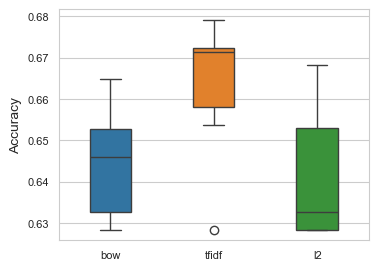

In [29]:
# PLot the results of bow, L2, and tdidf
plt.figure(figsize=(4,3))
ax = sns.boxplot(data=search_results, width=0.4)
ax.set_ylabel('Accuracy', fontsize=10)
ax.tick_params(labelsize=8)
plt.show()

In [30]:
# Retrieve the testing score for bow, l2, and tf-idf
m1 = simple_logistic_classify(X_tr_bow, y_tr, X_te_bow, y_te, 'bow',
                              _C = bow_search.best_params_['C'])
m2 = simple_logistic_classify(X_tr_l2, y_tr, X_te_l2, y_te, 'l2-normalized',
                              _C = l2_search.best_params_['C'])
m3 = simple_logistic_classify(X_tr_tfidf, y_tr, X_te_tfidf, y_te, 'tf-idf',
                              _C = tfidf_search.best_params_['C'])

Test score with bow features: 0.7085176991150443
Test score with l2-normalized features: 0.6814159292035398
Test score with tf-idf features: 0.7101769911504425


In [31]:
# Retrieve the results of the cross validation
bow_search.cv_results_['mean_test_score']

array([0.62831799, 0.62831799, 0.66480663, 0.6548496 , 0.64598527,
       0.64599141])